### EXP 1

In [2]:
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,Flatten,Dense

In [3]:
c=["I like deeplearing",
  "Deep learning models can learn word embeddings",
  "word embeddings capture semantic meaning of words",
  "neural network are powerfull for NLP tasks"]
t=Tokenizer()
t.fit_on_texts(c)
w_i=t.word_index
print("vocabulary:",w_i)

vocabulary: {'word': 1, 'embeddings': 2, 'i': 3, 'like': 4, 'deeplearing': 5, 'deep': 6, 'learning': 7, 'models': 8, 'can': 9, 'learn': 10, 'capture': 11, 'semantic': 12, 'meaning': 13, 'of': 14, 'words': 15, 'neural': 16, 'network': 17, 'are': 18, 'powerfull': 19, 'for': 20, 'nlp': 21, 'tasks': 22}


In [7]:
s=t.texts_to_sequences(c)
p_s=pad_sequences(s,padding='post')
print("\nSequences\n",p_s)
print("\nPadded sequences:\n",p_s)


Sequences
 [[ 3  4  5  0  0  0  0]
 [ 6  7  8  9 10  1  2]
 [ 1  2 11 12 13 14 15]
 [16 17 18 19 20 21 22]]

Padded sequences:
 [[ 3  4  5  0  0  0  0]
 [ 6  7  8  9 10  1  2]
 [ 1  2 11 12 13 14 15]
 [16 17 18 19 20 21 22]]


In [8]:
v_s=len(w_i)+1
e_dim=8
m_len=p_s.shape[1]

In [9]:
model=Sequential([Embedding(input_dim=v_s,output_dim=e_dim,input_length=m_len),Flatten(),Dense(10,activation='relu'),Dense(1,activation='sigmoid')])

/home/ailab/anaconda3/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [10]:
model.compile(optimizer='adam',loss='binary_crossentropy')

In [11]:
labels=np.array([1,0,1,0])
model.fit(p_s,labels,epochs=20,verbose=2)

Epoch 1/20
1/1 - 1s - 521ms/step - loss: 0.6791
Epoch 2/20
1/1 - 0s - 13ms/step - loss: 0.6751
Epoch 3/20
1/1 - 0s - 12ms/step - loss: 0.6711
Epoch 4/20
1/1 - 0s - 14ms/step - loss: 0.6671
Epoch 5/20
1/1 - 0s - 13ms/step - loss: 0.6632
Epoch 6/20
1/1 - 0s - 13ms/step - loss: 0.6597
Epoch 7/20
1/1 - 0s - 14ms/step - loss: 0.6563
Epoch 8/20
1/1 - 0s - 14ms/step - loss: 0.6529
Epoch 9/20
1/1 - 0s - 12ms/step - loss: 0.6497
Epoch 10/20
1/1 - 0s - 12ms/step - loss: 0.6465
Epoch 11/20
1/1 - 0s - 14ms/step - loss: 0.6432
Epoch 12/20
1/1 - 0s - 13ms/step - loss: 0.6398
Epoch 13/20
1/1 - 0s - 13ms/step - loss: 0.6363
Epoch 14/20
1/1 - 0s - 14ms/step - loss: 0.6328
Epoch 15/20
1/1 - 0s - 13ms/step - loss: 0.6293
Epoch 16/20
1/1 - 0s - 12ms/step - loss: 0.6257
Epoch 17/20
1/1 - 0s - 13ms/step - loss: 0.6221
Epoch 18/20
1/1 - 0s - 14ms/step - loss: 0.6183
Epoch 19/20
1/1 - 0s - 13ms/step - loss: 0.6145
Epoch 20/20
1/1 - 0s - 13ms/step - loss: 0.6106


In [12]:
em=model.layers[0].get_weights()[0]
print("\n word embeddings shape:",em.shape)


 word embeddings shape: (23, 8)


In [13]:
word="deep"
word_id=w_i[word]
print(f"Embedding for word'{word}':\n",em[word_id])

Embedding for word'deep':
 [ 0.02603764  0.03966664  0.04310608 -0.03815857 -0.01428638 -0.03475918
  0.00075923 -0.0349608 ]


In [14]:
word="learning"
word_id=w_i[word]
print(f"Embedding for word'{word}':\n",em[word_id])

Embedding for word'learning':
 [-0.0341787  -0.01803588 -0.02814111 -0.00525156  0.02283334  0.03009059
  0.03960098 -0.02334848]


### EXP 2

In [100]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import AdamW

In [107]:
x,y=make_moons(n_samples=500,noise=0.2,random_state=42)

In [108]:
print("Shape of x:",x.shape)
print("Shape of y:",y.shape)
print("First 5 samples of x:\n",x[:5])
print("First 5 samples of y:\n",y[:5])

Shape of x: (500, 2)
Shape of y: (500,)
First 5 samples of x:
 [[ 0.83085779 -0.33434228]
 [ 0.99170955  0.87899966]
 [ 1.1072453  -0.47034376]
 [-0.14089918  1.03314844]
 [ 0.40559217  1.32852876]]
First 5 samples of y:
 [1 0 1 0 0]


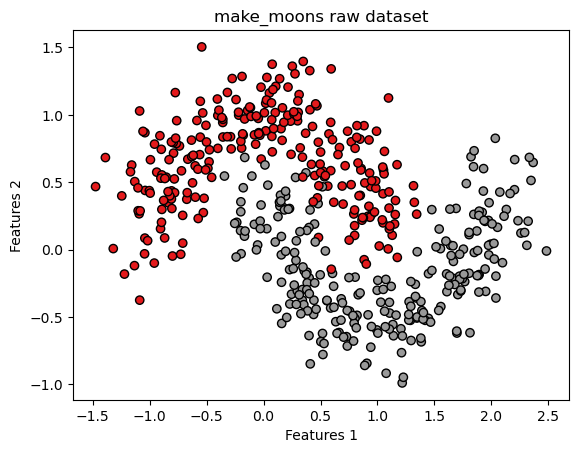

In [109]:
plt.scatter(x[:,0],x[:,1],c=y,cmap=plt.cm.Set1,edgecolor="k")
plt.title("make_moons raw dataset")
plt.xlabel("Features 1")
plt.ylabel("Features 2")
plt.show()

In [184]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
scalar=StandardScaler()
x_train=scalar.fit_transform(x_train)
x_test=scalar.transform(x_test)

In [185]:
model = Sequential([
    Dense(512, activation='relu', input_shape=(2,)),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

/home/ailab/anaconda3/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [186]:
model.compile(
    optimizer='adamW',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [187]:
history=model.fit(x_train,y_train,epochs=50,batch_size=32,verbose=0)
train_loss,train_acc=model.evaluate(x_train,y_train,verbose=0)
test_loss,test_acc=model.evaluate(x_test,y_test,verbose=0)

In [188]:
print("Training accuracy:",round(train_acc,3))
print("Testing accuracy:",round(test_acc,3))

Training accuracy: 0.993
Testing accuracy: 0.97


In [189]:
xx,yy=np.meshgrid(np.linspace(x[:,0].min()-0.5,x[:,0].max()+0.5,200),np.linspace(x[:,1].min()-0.5,x[:,1].max()+0.5,200))

In [190]:
z=model.predict(scalar.transform(np.c_[xx.ravel(),yy.ravel()]))

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 579us/step


In [191]:
z=(z>0.5).astype(int).reshape(xx.shape)

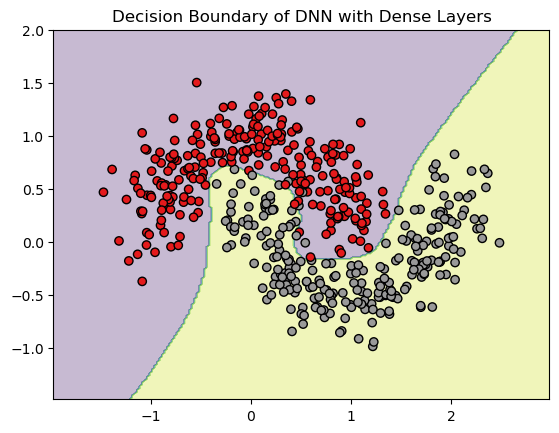

In [192]:
plt.contourf(xx,yy,z,alpha=0.3)
plt.scatter(x[:,0],x[:,1],c=y,cmap=plt.cm.Set1,edgecolor="k")
plt.title("Decision Boundary of DNN with Dense Layers")
plt.show()

### EXP 3

In [81]:
import tensorflow as tf
from tensorflow.keras import datasets,layers,models
import matplotlib.pyplot as plt
import numpy as np

In [82]:
(x_train,y_train),(x_test,y_test)=datasets.mnist.load_data()

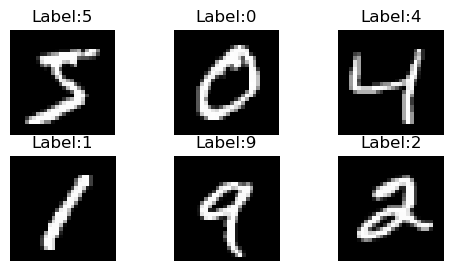

In [83]:
plt.figure(figsize=(6,3))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(x_train[i],cmap="gray")
    plt.title(f"Label:{y_train[i]}")
    plt.axis("off")
plt.show()    

In [84]:
x_train=x_train/255.0
x_test=x_test/255.0
x_train=x_train[...,np.newaxis]
x_test=x_test[...,np.newaxis]
model = models.Sequential([
    layers.Conv2D(8, (3, 3), activation='relu', input_shape=(28, 28, 1)),                          
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),                          
    layers.Dense(32, activation='relu'),                          
    layers.Dense(10, activation='softmax')                         
])

In [85]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 26, 26, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 13, 13, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 1352)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │        43,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,706 (170.73 KB)

 Trainable params: 43,706 (170.73 KB)

 Non-trainable params: 0 (0.00 B)

In [86]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(x_train, y_train, epochs=3, validation_data=(x_test, y_test))

Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8588 - loss: 0.4896 - val_accuracy: 0.9677 - val_loss: 0.1089
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9697 - loss: 0.1032 - val_accuracy: 0.9746 - val_loss: 0.0778
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9797 - loss: 0.0706 - val_accuracy: 0.9780 - val_loss: 0.0688


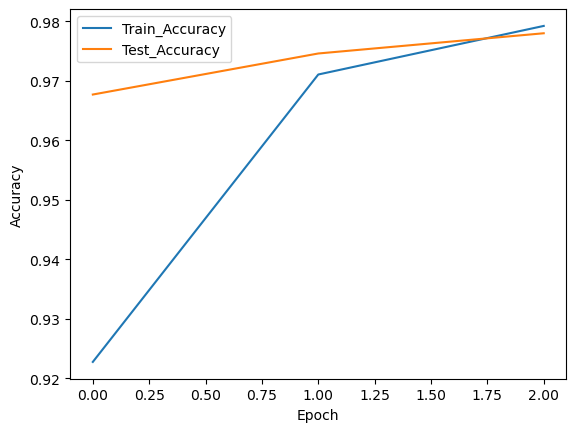

In [87]:
plt.plot(history.history['accuracy'],label='Train_Accuracy')
plt.plot(history.history['val_accuracy'],label='Test_Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

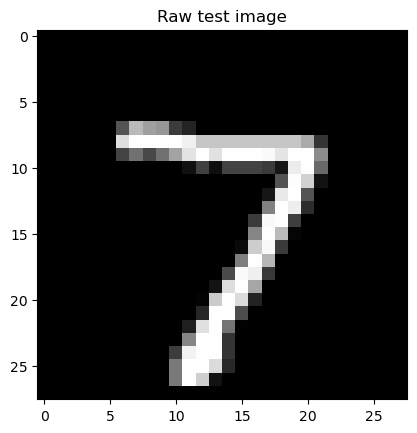

In [90]:
test_img=x_test[0]
plt.imshow(test_img.reshape(28,28),cmap="gray")
plt.title("Raw test image")
plt.show()

In [91]:
pred=model.predict(test_img[np.newaxis,...])
print("Model prediction:",np.argmax(pred))
print("True label:",y_test[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Model prediction: 7
True label: 7


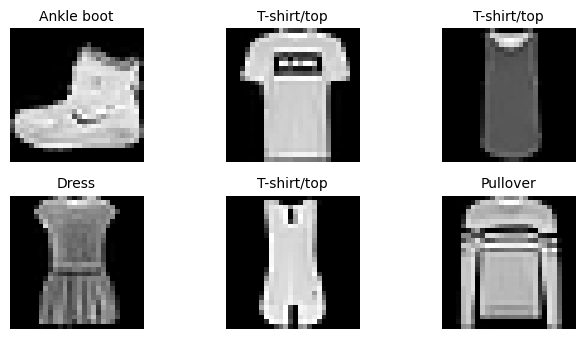

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 2704)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │       173,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 173,930 (679.41 KB)

 Trainable params: 173,930 (679.41 KB)

 Non-trainable params: 0 (0.00 B)

In [92]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

(x_train, y_train), (x_test, y_test) = datasets.fashion_mnist.load_data()

plt.figure(figsize=(7, 3.5))
for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.axis("off")
    plt.title(class_names[y_train[i]], fontsize=10)
plt.tight_layout()
plt.show()

x_train = x_train / 255.0
x_test = x_test / 255.0
x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]

model = models.Sequential([
    layers.Conv2D(16, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax') 
])
model.summary()

In [93]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(x_train, y_train, epochs=3, validation_data=(x_test, y_test))

Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8048 - loss: 0.5707 - val_accuracy: 0.8756 - val_loss: 0.3515
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8968 - loss: 0.2978 - val_accuracy: 0.8934 - val_loss: 0.3051
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9091 - loss: 0.2514 - val_accuracy: 0.8980 - val_loss: 0.2819


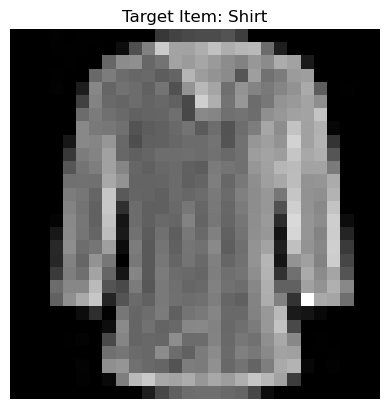

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Model Prediction: Shirt
True Label: Shirt


In [98]:
test_index = 4
test_img = x_test[test_index]

plt.imshow(test_img.reshape(28, 28), cmap="gray")
plt.axis("off")
plt.title(f"Target Item: {class_names[y_test[test_index]]}")
plt.show()

pred = model.predict(test_img[np.newaxis, ...])
predicted_class_idx = np.argmax(pred)

print("Model Prediction:", class_names[predicted_class_idx])
print("True Label:", class_names[y_test[test_index]])

### EXP 4

In [71]:
import tensorflow as tf
from tensorflow.keras import layers,models
import matplotlib.pyplot as plt

In [72]:
(x_train, _),(x_test, _)=tf.keras.datasets.mnist.load_data()

In [73]:
x_train=x_train.astype("float32")/255.0
x_test=x_test.astype("float32")/255.0
x_train=x_train.reshape(len(x_train),784)
x_test=x_test.reshape(len(x_test),784)

In [74]:
input_img=layers.Input(shape=(784,))
encoded=layers.Dense(128,activation='relu')(input_img)
encoded=layers.Dense(64,activation='relu')(encoded)
encoded=layers.Dense(32,activation='relu')(encoded)
# encoded=layers.Dense(16,activation='relu')(encoded)
# encoded=layers.Dense(8,activation='relu')(encoded)

In [75]:
decoded=layers.Dense(64,activation='relu')(encoded)
# decoded=layers.Dense(32,activation='relu')(decoded)
# decoded=layers.Dense(64,activation='relu')(decoded)
decoded=layers.Dense(128,activation='relu')(decoded)
decoded=layers.Dense(784,activation='sigmoid')(decoded)

In [76]:
autoencoder=models.Model(input_img,decoded)

In [77]:
autoencoder.compile(optimizer='adam',loss='mse')
autoencoder.fit(x_train,x_train,epochs=5,batch_size=256,shuffle=True,validation_data=(x_test,x_test))

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0976 - val_loss: 0.0381
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0343 - val_loss: 0.0262
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0255 - val_loss: 0.0222
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0219 - val_loss: 0.0197
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0196 - val_loss: 0.0181


In [78]:
decoded_img=autoencoder.predict(x_test)
n=5

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 589us/step


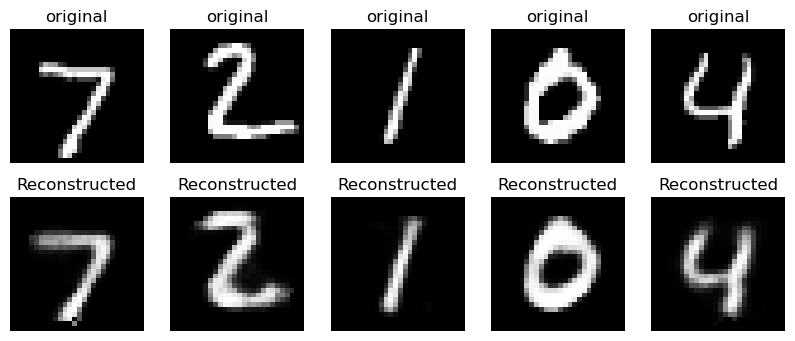

In [79]:
plt.figure(figsize=(10,4))
for i in range(n):
    ax=plt.subplot(2,n,i+1)
    plt.imshow(x_test[i].reshape(28,28),cmap='gray')
    plt.title("original")
    plt.axis("off")
    ax=plt.subplot(2,n,i+1+n)
    plt.imshow(decoded_img[i].reshape(28,28),cmap='gray')
    plt.title("Reconstructed")
    plt.axis("off")
plt.show()    

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0766 - val_loss: 0.0250
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0233 - val_loss: 0.0207
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0201 - val_loss: 0.0189
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0185 - val_loss: 0.0176
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0172 - val_loss: 0.0166
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 607us/step


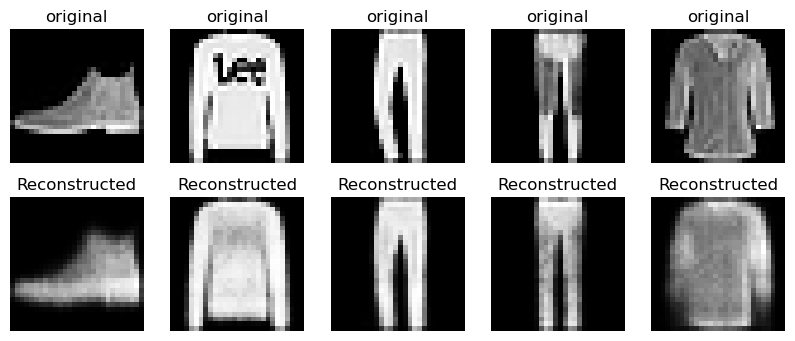

In [85]:
import tensorflow as tf
from tensorflow.keras import layers,models
import matplotlib.pyplot as plt
(x_train, _),(x_test, _)=tf.keras.datasets.fashion_mnist.load_data()
x_train=x_train.astype("float32")/255.0
x_test=x_test.astype("float32")/255.0
x_train=x_train.reshape(len(x_train),784)
x_test=x_test.reshape(len(x_test),784)
input_img=layers.Input(shape=(784,))
encoded=layers.Dense(128,activation='relu')(input_img)
encoded=layers.Dense(64,activation='relu')(encoded)
encoded=layers.Dense(32,activation='relu')(encoded)
# encoded=layers.Dense(16,activation='relu')(encoded)
# encoded=layers.Dense(8,activation='relu')(encoded)
decoded=layers.Dense(64,activation='relu')(encoded)
# decoded=layers.Dense(32,activation='relu')(decoded)
# decoded=layers.Dense(64,activation='relu')(decoded)
decoded=layers.Dense(128,activation='relu')(decoded)
decoded=layers.Dense(784,activation='sigmoid')(decoded)
autoencoder=models.Model(input_img,decoded)
autoencoder.compile(optimizer='adam',loss='mse')
autoencoder.fit(x_train,x_train,epochs=5,batch_size=256,shuffle=True,validation_data=(x_test,x_test))
decoded_img=autoencoder.predict(x_test)
n=5
plt.figure(figsize=(10,4))
for i in range(n):
    ax=plt.subplot(2,n,i+1)
    plt.imshow(x_test[i].reshape(28,28),cmap='gray')
    plt.title("original")
    plt.axis("off")
    ax=plt.subplot(2,n,i+1+n)
    plt.imshow(decoded_img[i].reshape(28,28),cmap='gray')
    plt.title("Reconstructed")
    plt.axis("off")
plt.show()    

### EXP 5

In [1]:
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,Flatten,Dense

2026-09-01 11:21:51.883767: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-01 11:21:51.884988: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-09-01 11:21:51.947441: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-09-01 11:21:52.174663: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-09-01 11:21:52.791526: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF

In [2]:
d=["I like deeplearing",
  "Deep learning is amazing",
  "I enjoy machine learning",
  "Natural Language Processing is fun",
  "I dislike bugs in code",
  "Debugging code can be hard",
  "I hate syntax errors",
  "Errors make me frustrated"]
labels=[1,1,1,1,0,0,0,0]
t=Tokenizer()
t.fit_on_texts(d)

In [5]:
s=t.texts_to_sequences(d)
print("word Index:",t.word_index)
print("Sequences:",s)
x=pad_sequences(s,maxlen=6)
y=np.array(labels)
print("padded sequences:\n",x)

word Index: {'i': 1, 'learning': 2, 'is': 3, 'code': 4, 'errors': 5, 'like': 6, 'deeplearing': 7, 'deep': 8, 'amazing': 9, 'enjoy': 10, 'machine': 11, 'natural': 12, 'language': 13, 'processing': 14, 'fun': 15, 'dislike': 16, 'bugs': 17, 'in': 18, 'debugging': 19, 'can': 20, 'be': 21, 'hard': 22, 'hate': 23, 'syntax': 24, 'make': 25, 'me': 26, 'frustrated': 27}
Sequences: [[1, 6, 7], [8, 2, 3, 9], [1, 10, 11, 2], [12, 13, 14, 3, 15], [1, 16, 17, 18, 4], [19, 4, 20, 21, 22], [1, 23, 24, 5], [5, 25, 26, 27]]
padded sequences:
 [[ 0  0  0  1  6  7]
 [ 0  0  8  2  3  9]
 [ 0  0  1 10 11  2]
 [ 0 12 13 14  3 15]
 [ 0  1 16 17 18  4]
 [ 0 19  4 20 21 22]
 [ 0  0  1 23 24  5]
 [ 0  0  5 25 26 27]]


In [8]:
model=Sequential([Embedding(input_dim=50,output_dim=8,input_length=6),Flatten(),Dense(10,activation='relu'),Dense(1,activation='sigmoid')])

/home/ailab/anaconda3/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [9]:
model.compile(optimizer='adam',loss='binary_crossentropy')

In [11]:
model.fit(x,y,epochs=20,verbose=2)

Epoch 1/20
1/1 - 1s - 596ms/step - loss: 0.6958
Epoch 2/20
1/1 - 0s - 13ms/step - loss: 0.6936
Epoch 3/20
1/1 - 0s - 14ms/step - loss: 0.6915
Epoch 4/20
1/1 - 0s - 13ms/step - loss: 0.6895
Epoch 5/20
1/1 - 0s - 13ms/step - loss: 0.6875
Epoch 6/20
1/1 - 0s - 12ms/step - loss: 0.6857
Epoch 7/20
1/1 - 0s - 14ms/step - loss: 0.6840
Epoch 8/20
1/1 - 0s - 14ms/step - loss: 0.6825
Epoch 9/20
1/1 - 0s - 14ms/step - loss: 0.6810
Epoch 10/20
1/1 - 0s - 13ms/step - loss: 0.6794
Epoch 11/20
1/1 - 0s - 13ms/step - loss: 0.6780
Epoch 12/20
1/1 - 0s - 14ms/step - loss: 0.6766
Epoch 13/20
1/1 - 0s - 12ms/step - loss: 0.6751
Epoch 14/20
1/1 - 0s - 13ms/step - loss: 0.6734
Epoch 15/20
1/1 - 0s - 13ms/step - loss: 0.6718
Epoch 16/20
1/1 - 0s - 13ms/step - loss: 0.6702
Epoch 17/20
1/1 - 0s - 13ms/step - loss: 0.6685
Epoch 18/20
1/1 - 0s - 14ms/step - loss: 0.6668
Epoch 19/20
1/1 - 0s - 14ms/step - loss: 0.6651
Epoch 20/20
1/1 - 0s - 12ms/step - loss: 0.6634


In [12]:
em=model.layers[0].get_weights()[0]
print("\n word embeddings shape:",em.shape)


 word embeddings shape: (50, 8)


In [14]:
test_text=["I love coding"]
test_seq=t.texts_to_sequences(test_text)
text_pad=pad_sequences(test_seq,maxlen=6)
prediction=model.predict(text_pad)
print("Prediction:",prediction)
print("Class:","Positive" if prediction>0.5 else Negative)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Prediction: [[0.50079465]]
Class: Positive


In [20]:
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,Flatten,Dense
d=["I like deeplearing",
  "Deep learning is amazing",
  "I enjoy machine learning",
  "Natural Language Processing is fun",
  "I dislike bugs in code",
  "Debugging code can be hard",
  "I hate syntax errors",
  "Errors make me frustrated"]
labels=[1,1,1,1,0,0,0,0]
t=Tokenizer()
t.fit_on_texts(d)
s=t.texts_to_sequences(d)
print("word Index:",t.word_index)
print("Sequences:",s)
x=pad_sequences(s,maxlen=6)
y=np.array(labels)
print("padded sequences:\n",x)
model=Sequential([Embedding(input_dim=50,output_dim=8,
                 input_length=6),Flatten(),Dense(10,activation='relu'),
                  Dense(1,activation='sigmoid')])
model.compile(optimizer='adam',loss='binary_crossentropy')
model.fit(x,y,epochs=20,verbose=1)
em=model.layers[0].get_weights()[0]
print("\n word embeddings shape:",em.shape)
test_text=["I love coding"]
test_seq=t.texts_to_sequences(test_text)
text_pad=pad_sequences(test_seq,maxlen=6)
prediction=model.predict(text_pad)
print("Prediction:",prediction)
print("Class:","Positive" if prediction>0.5 else "Negative")

word Index: {'i': 1, 'learning': 2, 'is': 3, 'code': 4, 'errors': 5, 'like': 6, 'deeplearing': 7, 'deep': 8, 'amazing': 9, 'enjoy': 10, 'machine': 11, 'natural': 12, 'language': 13, 'processing': 14, 'fun': 15, 'dislike': 16, 'bugs': 17, 'in': 18, 'debugging': 19, 'can': 20, 'be': 21, 'hard': 22, 'hate': 23, 'syntax': 24, 'make': 25, 'me': 26, 'frustrated': 27}
Sequences: [[1, 6, 7], [8, 2, 3, 9], [1, 10, 11, 2], [12, 13, 14, 3, 15], [1, 16, 17, 18, 4], [19, 4, 20, 21, 22], [1, 23, 24, 5], [5, 25, 26, 27]]
padded sequences:
 [[ 0  0  0  1  6  7]
 [ 0  0  8  2  3  9]
 [ 0  0  1 10 11  2]
 [ 0 12 13 14  3 15]
 [ 0  1 16 17 18  4]
 [ 0 19  4 20 21 22]
 [ 0  0  1 23 24  5]
 [ 0  0  5 25 26 27]]
Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step - loss: 0.6987
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.6960
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.6935
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.6915
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms

/home/ailab/anaconda3/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/stepWARNING:tensorflow:6 out of the last 6 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x7fb46d21a3b0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


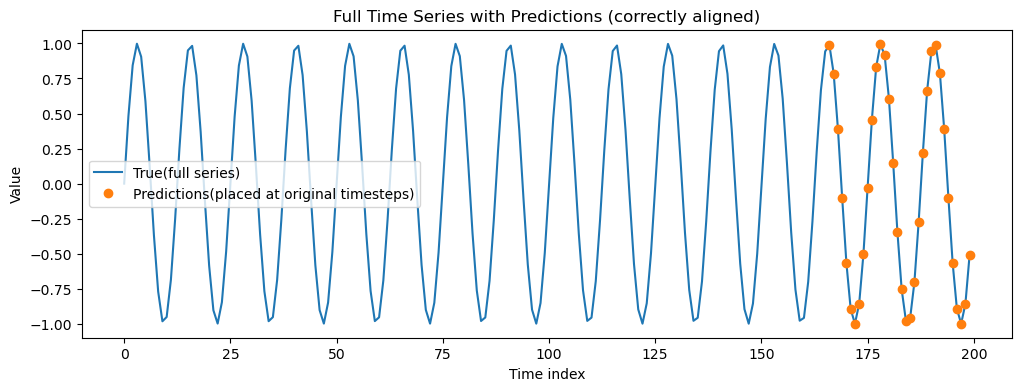

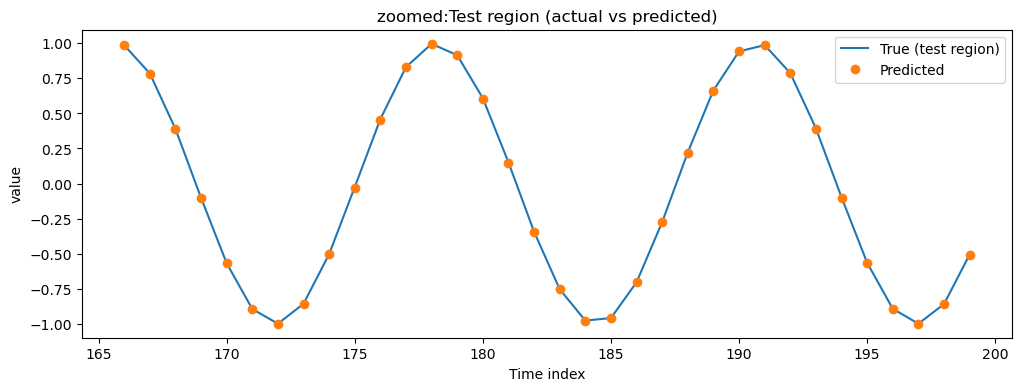

sample actual vs predicted values(test window):
Index 166->actual:0.9864	 Predicted:0.9869
Index 167->actual:0.7854	 Predicted:0.7834
Index 168->actual:0.3902	 Predicted:0.3867
Index 169->actual:-0.1014	 Predicted:-0.1043
Index 170->actual:-0.5680	 Predicted:-0.5694
Index 171->actual:-0.8942	 Predicted:-0.8944
Index 172->actual:-0.9993	 Predicted:-0.9987
Index 173->actual:-0.8573	 Predicted:-0.8568
Index 174->actual:-0.5033	 Predicted:-0.5046
Index 175->actual:-0.0249	 Predicted:-0.0287


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM,Dense
from sklearn.preprocessing import MinMaxScaler

data=np.sin(np.linspace(0,100,200)).reshape(-1,1)
scaler=MinMaxScaler(feature_range=(0,1))
data_scaled=scaler.fit_transform(data)
window_size=30
X,y=[],[]
for i in range(len(data_scaled)-window_size):
    X.append(data_scaled[i:i+window_size])
    y.append(data_scaled[i+window_size])
    
X=np.array(X)
y=np.array(y)
split=int(0.8*len(X))
X_train,X_test=X[:split],X[split:]
y_train,y_test=y[:split],y[split:]

model=Sequential([
    LSTM(50,activation='tanh',input_shape=(window_size,1))
    ,Dense(1)])
model.compile(optimizer='adam',loss='mse')
model.fit(X_train,y_train,epochs=50,batch_size=16,validation_data=(X_test,y_test),verbose=0)
pred_scaled=model.predict(X_test)
pred=scaler.inverse_transform(pred_scaled)

y_test_inv=scaler.inverse_transform(y_test)

data_full=data.flatten()
pred_full=np.full_like(data_full,np.nan)

for i in range(len(pred)):
    orig_index=window_size+split+i
    pred_full[orig_index]=pred[i,0]
    
plt.figure(figsize=(12,4))
plt.plot(data_full,label='True(full series)')
plt.plot(pred_full,marker='o',linestyle='',label='Predictions(placed at original timesteps)')
plt.title('Full Time Series with Predictions (correctly aligned)')
plt.legend()
plt.xlabel('Time index')
plt.ylabel('Value')
plt.show()

test_start=window_size+split
test_end=len(data_full)
plt.figure(figsize=(12,4))
plt.plot(range(test_start,test_end),data_full[test_start:test_end],label='True (test region)')
plt.plot(range(test_start,test_end),pred_full[test_start:test_end],marker='o',linestyle='',label='Predicted')
plt.title('zoomed:Test region (actual vs predicted)')
plt.legend()
plt.xlabel('Time index')
plt.ylabel('value')
plt.show()

print("sample actual vs predicted values(test window):")
for i in range(min(10,len(pred))):
    actual=float(y_test_inv[i])
    predicted_value=float(pred[i])
    print(f"Index {window_size+split+i:03d}->actual:{actual:.4f}\t Predicted:{predicted_value:.4f}")

### EXP 7

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.utils import image_dataset_from_directory
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file(
    "flower_photos",
    origin=dataset_url,
    untar=True)
img_height, img_width = 224, 224
batch_size = 32
train_ds = image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)
val_ds = image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.


Class names: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


2026-09-25 12:48:15.977489: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


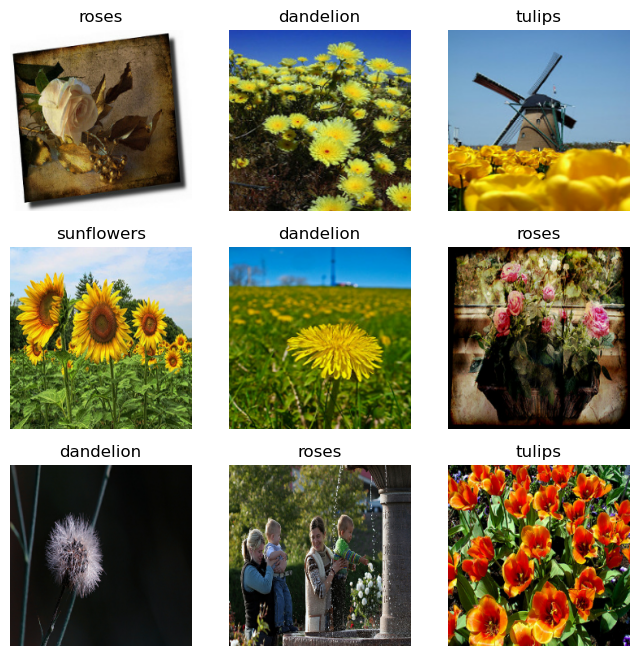

In [21]:
class_names = train_ds.class_names
print("Class names:", class_names)
plt.figure(figsize=(8, 8))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()

In [22]:
train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y))
val_ds = val_ds.map(lambda x, y: (preprocess_input(x), y))
base_model = MobileNetV2(weights="imagenet",include_top=False,input_shape=(img_height, img_width, 3))
base_model.trainable = False
model = models.Sequential([base_model,layers.GlobalAveragePooling2D(),layers.Dense(128, activation="relu"),layers.Dense(len(class_names), activation="softmax")])
model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])
history = model.fit(train_ds,validation_data=val_ds,epochs=3)

Epoch 1/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 56s 592ms/step - accuracy: 0.7058 - loss: 0.8421 - val_accuracy: 0.8856 - val_loss: 0.3354
Epoch 2/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 55s 601ms/step - accuracy: 0.9075 - loss: 0.2609 - val_accuracy: 0.8733 - val_loss: 0.3540
Epoch 3/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 55s 592ms/step - accuracy: 0.9461 - loss: 0.1726 - val_accuracy: 0.9101 - val_loss: 0.2843


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 991ms/step


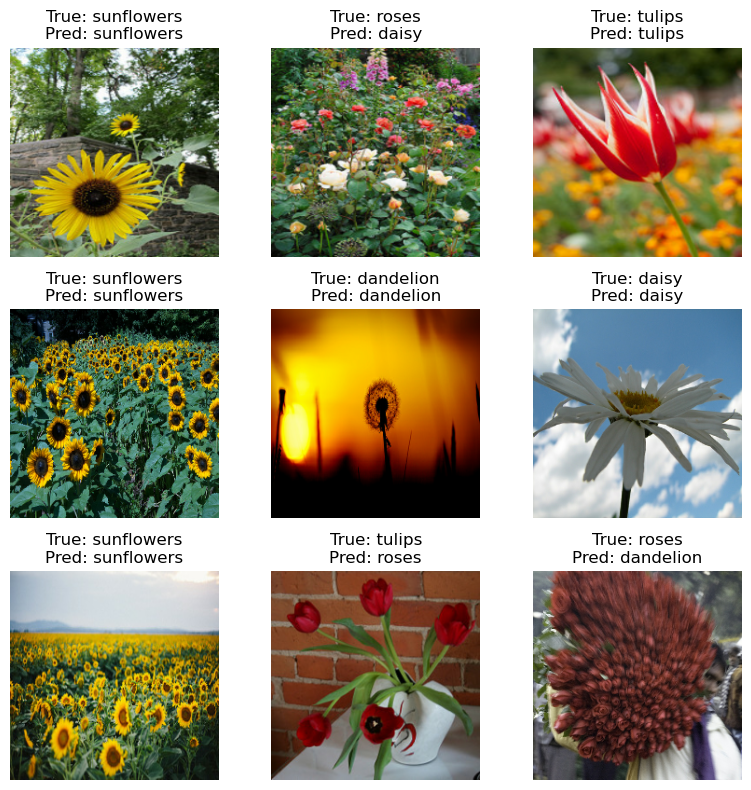

2026-09-25 12:51:18.620527: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 520ms/step
Softmax probabilities: [[2.2598806e-04 5.9186056e-04 6.7668509e-05 9.9910933e-01 5.1310080e-06]]
Predicted class: sunflowers
Prediction probability: 0.9991093


In [23]:
for images, labels in val_ds.take(1):
    predictions = model.predict(images)
    pred_labels = np.argmax(predictions, axis=1)
    plt.figure(figsize=(8, 8))
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        img = (images[i].numpy() + 1) / 2
        plt.imshow(img)
        plt.title(
            f"True: {class_names[labels[i]]}\n"
            f"Pred: {class_names[pred_labels[i]]}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()
sample_img = images[0:1]
softmax_output = model.predict(sample_img)
predicted_class = np.argmax(softmax_output[0])
print("Softmax probabilities:", softmax_output)
print("Predicted class:", class_names[predicted_class])
print("Prediction probability:", softmax_output[0][predicted_class])